<a href="https://colab.research.google.com/github/Saifullah785/Python_for_Data_Science/blob/main/Data_Analysis_Process(EDA)/Lecture_on_EDA_Data_Analysis_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Overview

This notebook contains an exploratory data analysis (EDA) of the Titanic dataset. The analysis covers:

*   **Data Loading and Initial Inspection**: Loading the dataset and displaying basic information.
*   **Univariate Analysis**: Analyzing the distribution and characteristics of individual numerical and categorical features, including handling missing values and identifying outliers.
*   **Bivariate Analysis**: Exploring the relationships between pairs of features, particularly focusing on how they relate to the 'Survived' column.
*   **Feature Engineering**: Creating new features ('individual_fare', 'family_size', 'family_type', 'surname', 'title', 'deck') from existing ones to potentially improve model performance.

The notebook aims to understand the data, identify patterns, and prepare the data for subsequent machine learning tasks.

#**Exploratory Data Analysis | Data Analysis Process**

In [1]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
# loading the dataset

df = pd.read_csv('train.csv')

# Why do EDA

- Model Building

- Analysis an reporting

- Validate assumptions

- Handling missing values

- feature engineering

- detecting outliers

# column Types

- **Numerical** -Age,Fare,Passengerid

- **Categorical** -Survived, Pclass, Sex, SibSp, Parch,Embarked

- **Mixed** -Name, Ticket, Cabin

### Univariate Analysis

Univariate analysis focuses on analyzing each feature in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

#### The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include:

- **Normal Distribution**: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

- **Skewed Distribution**: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

- **Bimodal Distribution**: A distribution with two peaks or modes.

- **Uniform Distribution**: A distribution where all values have an equal chance of occurring.

The shape of the data distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.

#### **Dispersion** is a statistical term used to describe the spread or variability of a set of data. It measures how far the values in a data set are spread out from the central tendency (mean, median, or mode) of the data.

There are several measures of dispersion, including:

- **Range**: The difference between the largest and smallest values in a data set.

- **Variance**: The average of the squared deviations of each value from the mean of the data set.

- **Standard Deviation**: The square root of the variance. It provides a measure of the spread of the data that is in the same units as the original data.

- **Interquartile range (IQR)**: The range between the first quartile (25th percentile) and the third quartile (75th percentile) of the data.

Dispersion helps to describe the spread of the data, which can help to identify the presence of outliers and skewness in the data.

### Steps of doing Univariate Analysis on Numerical columns

- **Descriptive Statistics**: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations**: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include histograms, box plots, and density plots. These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers**: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness**: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


### Age

**conclusions**

- Age is normally(almost) distributed
- 20% of the values are missing
- There are some outliers

In [108]:
# Display descriptive statistics for the 'Age' column
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


<Axes: ylabel='Frequency'>

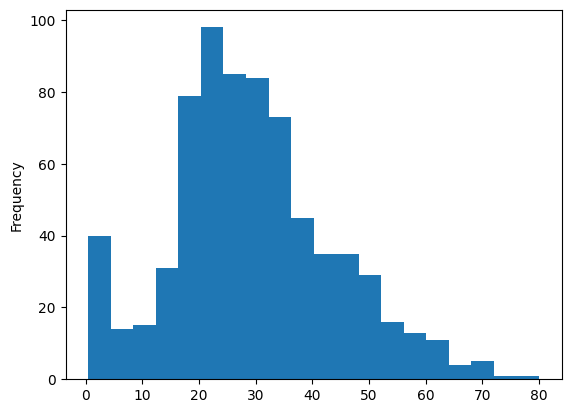

In [109]:
# Plot a histogram of the 'Age' column with 20 bins
df['Age'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

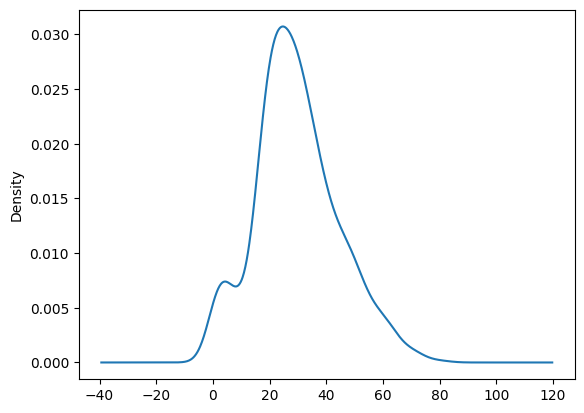

In [110]:
# Plot a kernel density estimate (KDE) of the 'Age' column
df['Age'].plot(kind='kde')

In [111]:
# Calculate the skewness of the 'Age' column
df['Age'].skew()

np.float64(0.38910778230082704)

<Axes: >

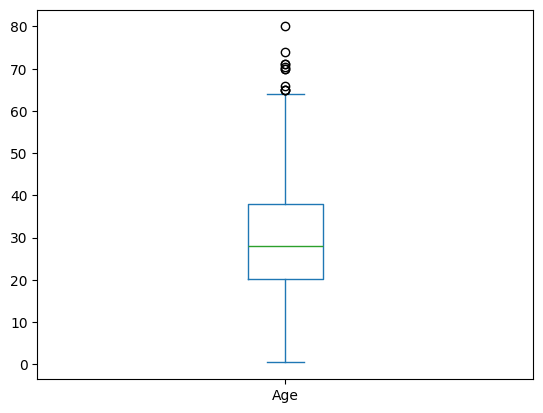

In [112]:
# Plot a box plot of the 'Age' column
df['Age'].plot(kind='box')

In [113]:
# Filter the DataFrame to show rows where 'Age' is greater than 65
df[df['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [114]:
# Calculate the percentage of missing values in the 'Age' column
df['Age'].isnull().sum()/len(df['Age'])

np.float64(0.19865319865319866)

# Fare

conclusions

- the data is highly(positively) skewed

- fare col actually contains the group fare and not the individual fare (this might be and issue)

- we need to creae a new col individual fare

In [115]:
# Display descriptive statistics for the 'Fare' column
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: ylabel='Frequency'>

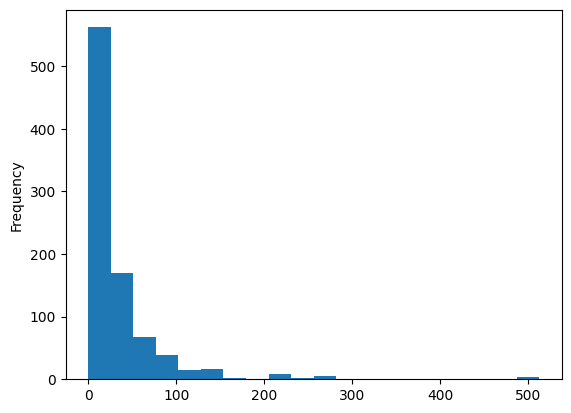

In [116]:
# Plot a histogram of the 'Fare' column with 20 bins
df['Fare'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

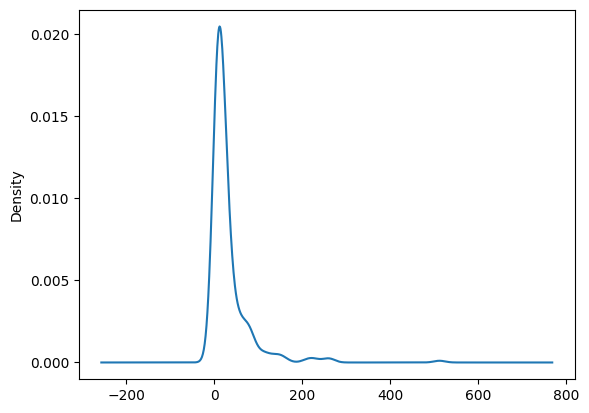

In [117]:
# Plot a kernel density estimate (KDE) of the 'Fare' column
df['Fare'].plot(kind='kde')

In [118]:
# Calculate the skewness of the 'Fare' column
df['Fare'].skew()

np.float64(4.787316519674893)

<Axes: >

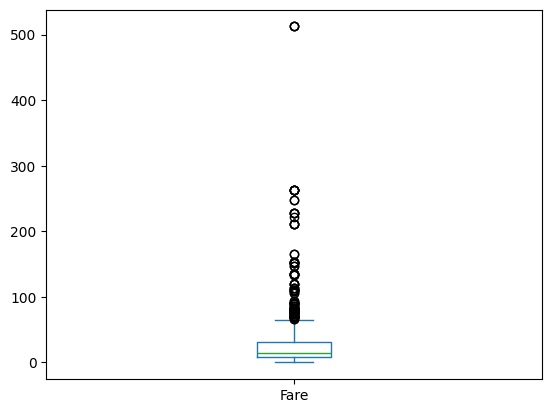

In [119]:
# Plot a box plot of the 'Fare' column
df['Fare'].plot(kind='box')

In [120]:
# Filter the DataFrame to show rows where 'Fare' is greater than 250
df[df['Fare'] > 250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [121]:
# Calculate the percentage of missing values in the 'Fare' column
df['Fare'].isnull().sum()/len(df['Fare'])

np.float64(0.0)

### Steps of doing Univariate Analysis on Categorical columns

**Descriptive Statistics**: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations**: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

**Missing Values**: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

**Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

### Survived

**conclustions**

- Parch and SibSp cols can be merged to form a new col call family_size

- Create a new col called is_alone

In [122]:
# Display the frequency distribution of the 'Survived' column
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


<Axes: xlabel='Survived'>

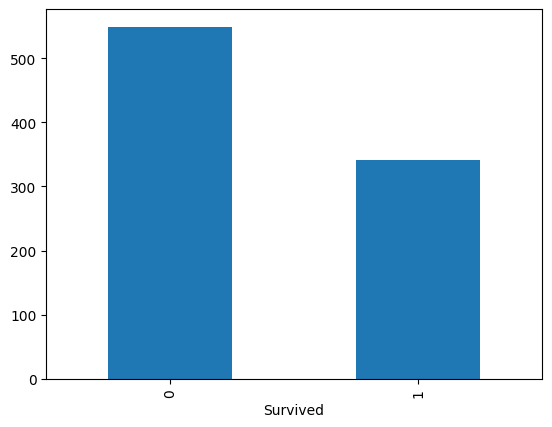

In [123]:
# Plot a bar chart of the frequency distribution of the 'Survived' column
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

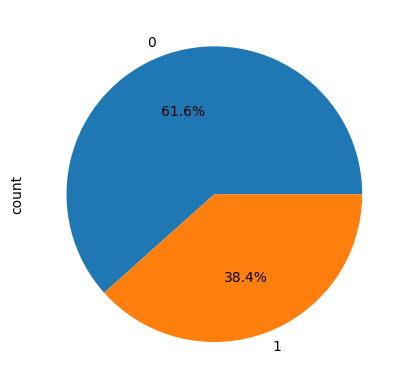

In [124]:
# Plot a pie chart of the frequency distribution of the 'Survived' column with percentages
df['Survived'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [125]:
# Calculate the percentage of missing values in the 'Survived' column
df['Survived'].isnull().sum()/len(df['Survived'])

np.float64(0.0)

**visualizing the column of Pclass**

In [126]:
# Display the frequency distribution of the 'Pclass' column
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


<Axes: xlabel='Pclass'>

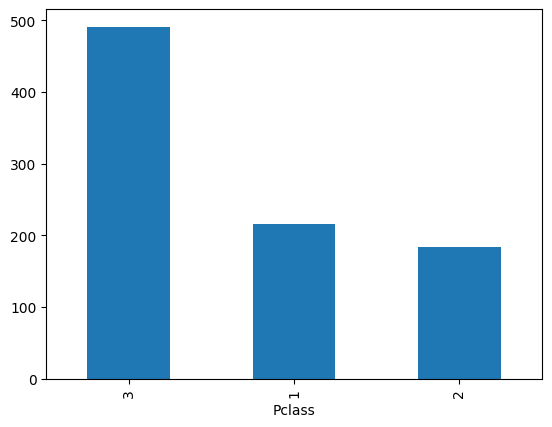

In [127]:
# Plot a bar chart of the frequency distribution of the 'Pclass' column
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

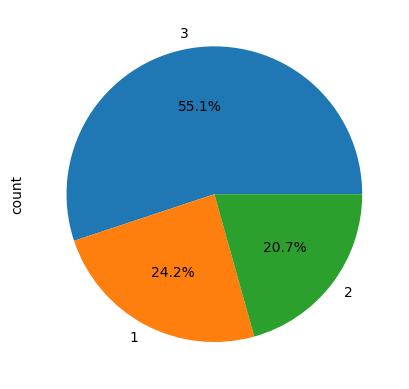

In [128]:
# Plot a pie chart of the frequency distribution of the 'Pclass' column with percentages
df['Pclass'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [129]:
# Calculate the percentage of missing values in the 'Pclass' column
df['Pclass'].isnull().sum()/len(df['Survived'])

np.float64(0.0)

**visuaizing the column of sex**

In [130]:
# Display the frequency distribution of the 'Sex' column
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex'>

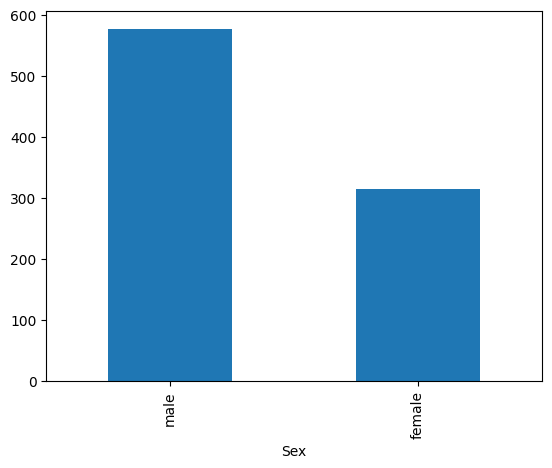

In [131]:
# Plot a bar chart of the frequency distribution of the 'Sex' column
df['Sex'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

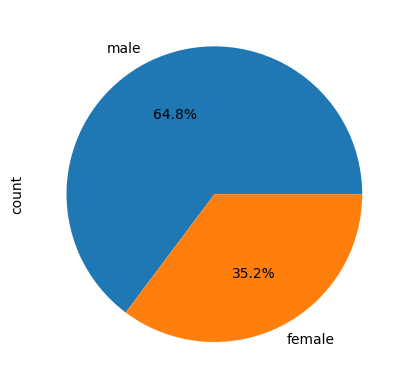

In [132]:
# Plot a pie chart of the frequency distribution of the 'Sex' column with percentages
df['Sex'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [133]:
# Calculate the percentage of missing values in the 'Sex' column
df['Sex'].isnull().sum()/len(df['Sex'])

np.float64(0.0)

**visualizing the column of SibSp**

In [134]:
# Display the frequency distribution of the 'SibSp' column
df['SibSp'].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


<Axes: xlabel='SibSp'>

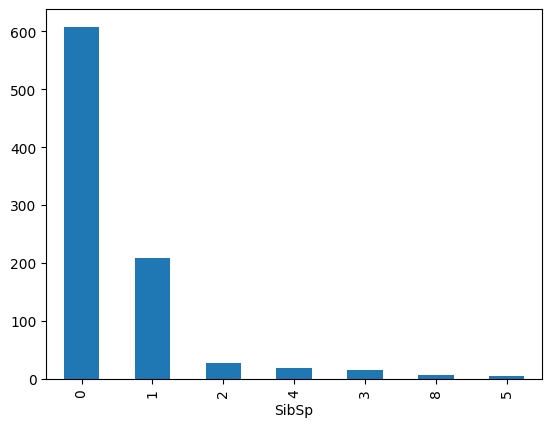

In [135]:
# Plot a bar chart of the frequency distribution of the 'SibSp' column
df['SibSp'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

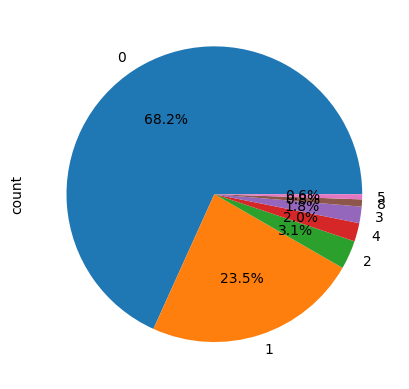

In [136]:
# Plot a pie chart of the frequency distribution of the 'SibSp' column with percentages
df['SibSp'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [137]:
# Calculate the percentage of missing values in the 'SibSp' column
df['SibSp'].isnull().sum()/len(df['SibSp'])

np.float64(0.0)

**visualizing the column of Parch**

In [138]:
# Display the frequency distribution of the 'Parch' column
df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


<Axes: xlabel='Parch'>

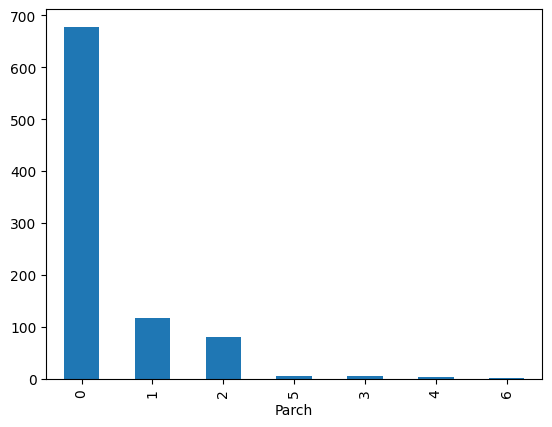

In [139]:
# Plot a bar chart of the frequency distribution of the 'Parch' column
df['Parch'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

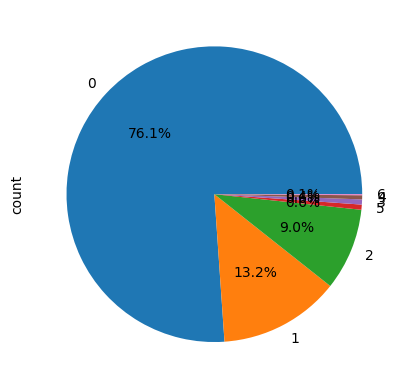

In [140]:
# Plot a pie chart of the frequency distribution of the 'Parch' column with percentages
df['Parch'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [141]:
# Calculate the percentage of missing values in the 'Parch' column
df['Parch'].isnull().sum()/len(df['Parch'])

np.float64(0.0)

**visualizing the column of Embarked**

In [142]:
# Display the frequency distribution of the 'Embarked' column
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


<Axes: xlabel='Embarked'>

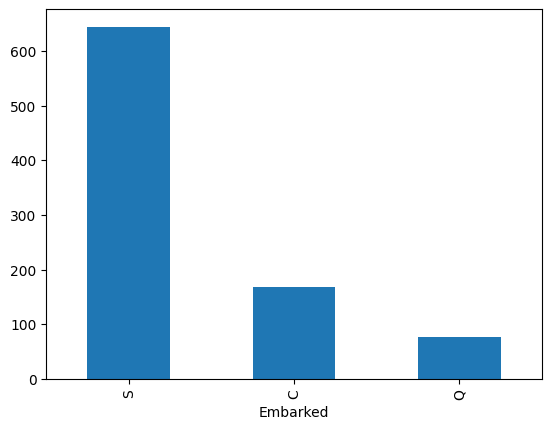

In [143]:
# Plot a bar chart of the frequency distribution of the 'Embarked' column
df['Embarked'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

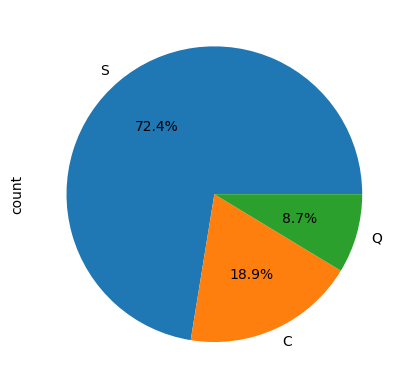

In [144]:
# Plot a pie chart of the frequency distribution of the 'Embarked' column with percentages
df['Embarked'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [145]:
# Calculate the percentage of missing values in the 'Embarked' column
df['Embarked'].isnull().sum()/len(df['Embarked'])

np.float64(0.002244668911335578)

### Steps of doing Bivariate Analysis

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical data across different categories of the categorical data.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps
        
- Write your conclusions

In [146]:
# Display the first 5 rows of the DataFrame
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='Survived'>

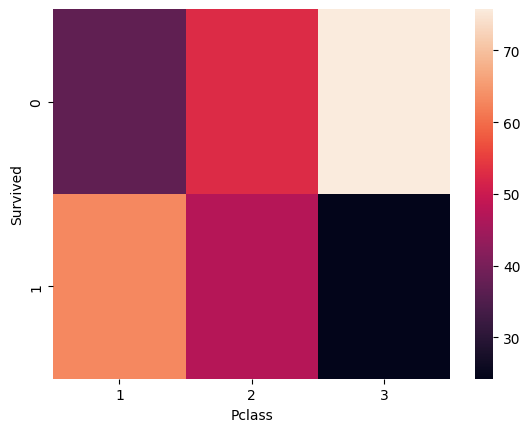

In [147]:
# Plot a heatmap of the cross-tabulation of 'Survived' and 'Pclass', normalized by columns
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'],normalize='columns')*100)

In [148]:
# Create a cross-tabulation of 'Survived' and 'Sex', normalized by columns and multiplied by 100
pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [149]:
# Create a cross-tabulation of 'Survived' and 'Embarked', normalized by columns and multiplied by 100
pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [150]:
# Create a cross-tabulation of 'Sex' and 'Embarked', normalized by columns and multiplied by 100
pd.crosstab(df['Sex'],df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [151]:
# Create a cross-tabulation of 'Pclass' and 'Embarked', normalized by columns and multiplied by 100
pd.crosstab(df['Pclass'],df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


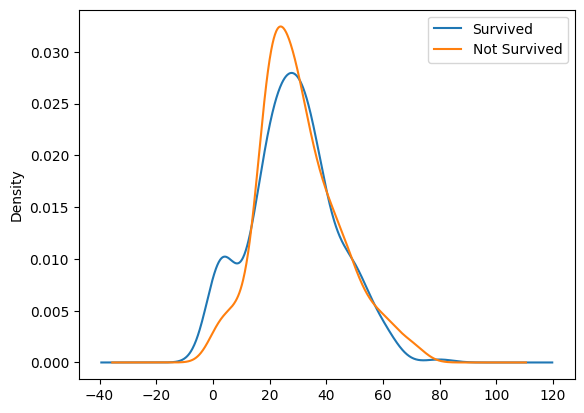

In [152]:
# Plot the kernel density estimate of 'Age' for survived and not survived passengers
df[df['Survived'] == 1]['Age'].plot(kind='kde',label = 'Survived')
df[df['Survived'] == 0]['Age'].plot(kind='kde',label = 'Not Survived')
plt.legend()
plt.show()

In [153]:
# Calculate the mean age of passengers in Pclass 1
df[df['Pclass']==1]['Age'].mean()

np.float64(38.233440860215055)

# Feature Engineering on Fare col

In [154]:
# Filter the DataFrame to show rows where 'Ticket' is 'CA. 2343'
df[df['Ticket'] == 'CA. 2343' ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [155]:
# Filter the DataFrame to show rows where 'Name' contains 'Sage'
df[df['Name'].str.contains('Sage')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.30,B35,C
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [156]:
# Load the test dataset
df1 = pd.read_csv('/content/test.csv')

In [157]:
# Concatenate the train and test DataFrames
pd.concat([df,df1])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [158]:
# Filter the DataFrame to show rows where 'Ticket' is 'CA. 2343'
df[df['Ticket'] == 'CA. 2343' ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [159]:
# Display the frequency distribution of the 'Ticket' column
df['Ticket'].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [160]:
# Create a new column 'individual_fare' by dividing 'Fare' by the total number of family members (SibSp + Parch + 1)
df['individual_fare'] = df['Fare']/(df['SibSp'] + df['Parch'] + 1)

In [161]:
# Display descriptive statistics for the 'individual_fare' column
df['individual_fare'].describe()

,individual_fare
count,891.000000
mean,19.916375
std,35.841257
min,0.000000
25%,7.250000
50%,8.300000
75%,23.666667
max,512.329200


In [162]:
# Display the 'Fare' column
df['Fare']

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


In [163]:
# Display the entire DataFrame
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000


In [164]:
# Create a new column 'family_size' by summing 'SibSp' and 'Parch' and adding 1
df['family_size'] = df['SibSp'] + df['Parch'] + 1

In [165]:
# Define a function to categorize family size into 'alone', 'small', or 'large'
# family_type
# 1 -> alone
# 2-4 -> small
# >5 -> large

def transform_family_size(num):
  if num == 1:
    return 'alone'
  elif num > 1 and num <= 5:
    return 'small'
  else:
    return 'large'

In [166]:
# Apply the transform_family_size function to the 'family_size' column to create 'family_type'
df['family_type'] = df['family_size'].apply(transform_family_size)

In [167]:
# Display the DataFrame with the new 'family_size' and 'family_type' columns
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,13.00000,1,alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,30.00000,1,alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,5.86250,4,small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,30.00000,1,alone


In [168]:
# Create a cross-tabulation of 'Survived' and 'family_type', normalized by columns and multiplied by 100
pd.crosstab(df['Survived'],df['family_type'],normalize='columns')*100

family_type,alone,large,small
Survived,,,
0,69.646182,85.106383,43.973941
1,30.353818,14.893617,56.026059


In [169]:
# Extract the surname from the 'Name' column and create a new 'surname' column
df['surname'] = df['Name'].str.split(',').str.get(0)

In [170]:
# Display the first 5 rows of the DataFrame with the new 'surname' column
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2,small,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1,alone,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1,alone,Allen


In [171]:
# Extract the title from the 'Name' column and create a new 'title' column
df['title'] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [172]:
# Display the frequency distribution of the 'title' column
df['title'].value_counts()

,count
title,
Mr.,517
Miss.,182
Mrs.,125
Master.,40
Dr.,7
Rev.,6
Col.,2
Mlle.,2
Major.,2


In [173]:
# Replace less frequent titles with 'other' in the 'title' column
df['title'].replace(['Rev.','Dr.','Col.','Major.','Don.','Capt.','the','Jonkheer.'],'other')

,title
0,Mr.
1,Mrs.
2,Miss.
3,Mrs.
4,Mr.
...,...
886,other
887,Miss.
888,Miss.
889,Mr.


In [174]:
# Display the 'title' column with the updated values
df['title']

,title
0,Mr.
1,Mrs.
2,Miss.
3,Mrs.
4,Mr.
...,...
886,Rev.
887,Miss.
888,Miss.
889,Mr.


In [175]:
# Filter the DataFrame to include only rows where 'title' is one of the specified common titles
temp_df = df[df['title'].isin(['Mr.','Miss','Mrs.','Master.','other'])]

In [176]:
# Create a cross-tabulation of 'Survived' and the filtered 'title' column, normalized by columns and multiplied by 100
pd.crosstab(temp_df['Survived'],temp_df['title'],normalize='columns')*100

title,Master.,Mr.,Mrs.
Survived,,,
0,42.5,84.332689,20.8
1,57.5,15.667311,79.2


In [177]:
# Calculate the percentage of missing values in the 'Cabin' column
df['Cabin'].isnull().sum()/len(df['Cabin'])

np.float64(0.7710437710437711)

In [178]:
# Display the top 15 most frequent values in the 'Cabin' column
df['Cabin'].value_counts().head(15)

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
E101,3
C22 C26,3
F33,3
C83,2


In [179]:
# Fill missing values in the 'Cabin' column with 'M'
df['Cabin'].fillna('M',inplace=True)

In [180]:
# Display the frequency distribution of the 'Cabin' column after filling missing values
df['Cabin'].value_counts()

,count
Cabin,
M,687
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
...,...
E17,1
A24,1
C50,1


In [181]:
# Extract the first letter of the 'Cabin' column to create a 'deck' column
df['deck'] = df['Cabin'].str[0]

In [182]:
# Display the frequency distribution of the 'deck' column
df['deck'].value_counts()

,count
deck,
M,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [183]:
# Create a cross-tabulation of 'deck' and 'Pclass'
pd.crosstab(df['deck'],df['Pclass'])

Pclass,1,2,3
deck,,,
A,15,0,0
B,47,0,0
C,59,0,0
D,29,4,0
E,25,4,3
F,0,8,5
G,0,0,4
M,40,168,479
T,1,0,0


In [184]:
# Create a cross-tabulation of 'Survived' and 'deck', normalized by columns and multiplied by 100
pd.crosstab(df['Survived'],df['deck'],normalize='columns')*100

deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,70.014556,100.0
1,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,29.985444,0.0


<Axes: xlabel='deck'>

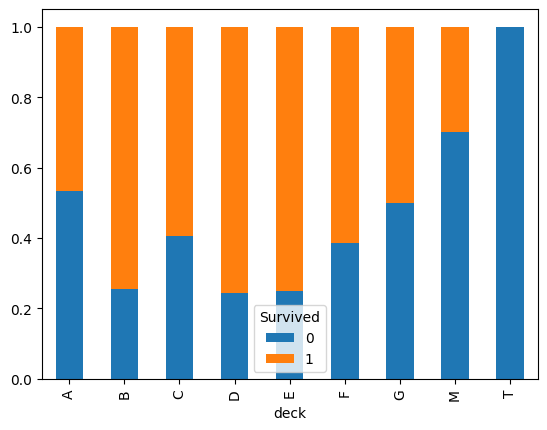

In [185]:
# Plot a stacked bar chart of the cross-tabulation of 'deck' and 'Survived', normalized by index
pd.crosstab(df['deck'],df['Survived'],normalize='index').plot(kind='bar',stacked=True)

<Axes: >

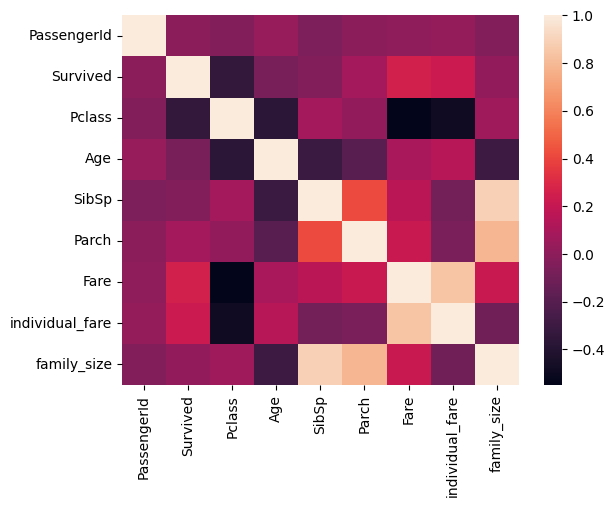

In [186]:
# Plot a heatmap of the correlation matrix of the numerical columns in the DataFrame
sns.heatmap(df.select_dtypes(include=np.number).corr())

In [187]:
# Calculate the correlation of all numerical columns with the 'Survived' column
df.select_dtypes(include=np.number).corr()['Survived']

,Survived
PassengerId,-0.005007
Survived,1.000000
Pclass,-0.338481
Age,-0.077221
SibSp,-0.035322
Parch,0.081629
Fare,0.257307
individual_fare,0.221600
family_size,0.016639


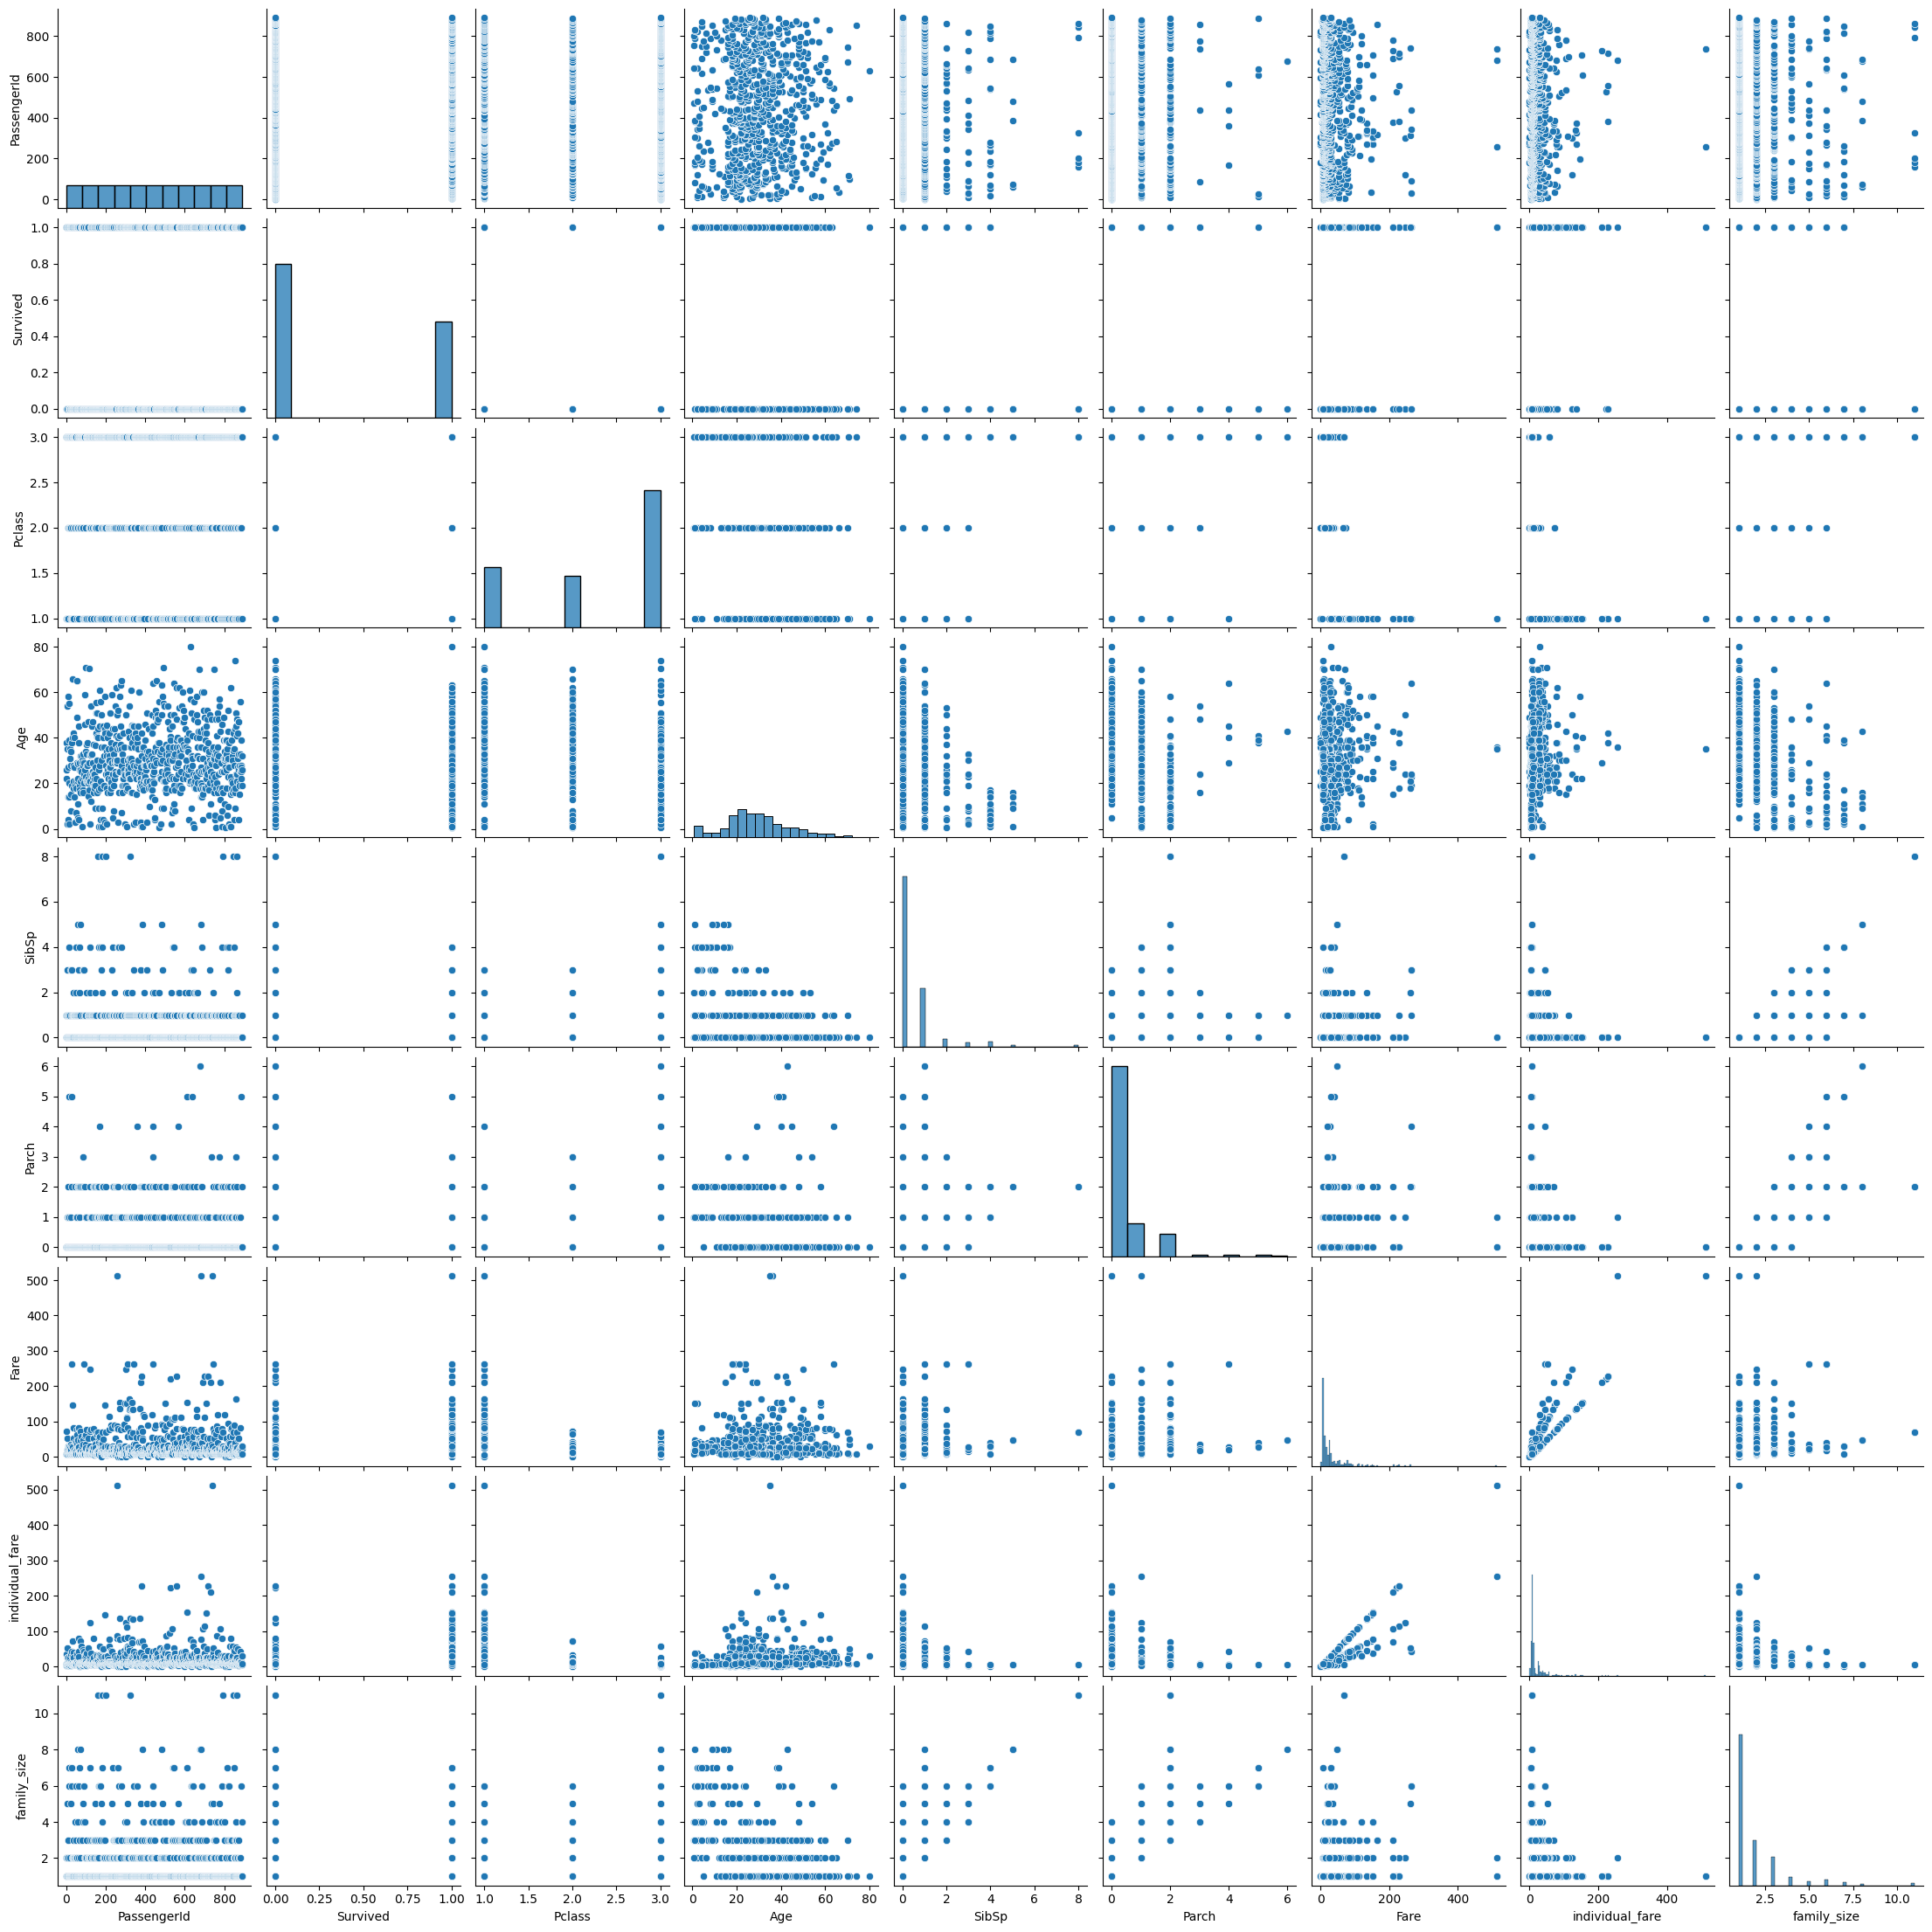

In [188]:
# Create a pair plot of the numerical columns in the DataFrame
sns.pairplot(df.select_dtypes(include=np.number))

You've done a great job with the exploratory data analysis and feature engineering! Here are some potential next steps to continue your work:

*   **Address missing values**: You still have missing values in the 'Age' and 'Embarked' columns. Decide on a strategy to handle them (e.g., imputation, removal) before building a model.
*   **Encode categorical features**: Convert categorical columns ('Sex', 'Embarked', 'family_type', 'title', 'deck') into a numerical format that can be used by machine learning models. One-hot encoding is a common technique for this.
*   **Scale numerical features**: Consider scaling or standardizing your numerical features ('Age', 'Fare', 'individual_fare', 'family_size') if you plan to use models that are sensitive to the scale of the data (e.g., models that use distance calculations).
*   **Select a model**: Choose a machine learning model appropriate for your task (binary classification to predict 'Survived').
*   **Train and evaluate the model**: Split your data into training and testing sets, train your chosen model, and evaluate its performance using appropriate metrics.
*   **Tune hyperparameters**: Optimize your model's performance by tuning its hyperparameters.
*   **Make predictions**: Use your trained model to make predictions on new data.